## Load modules

In [18]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import panel as pn

In [19]:
scrabble_df = pd.read_csv('./Spiele-Tabelle.csv')

In [20]:
scrabble_players = ['Deniz', 'Danyel', 'Robin']

palette = {
    "Deniz": "tab:green",
    "Danyel": "tab:orange", 
    "Robin": "tab:blue",
    "Unentschieden": "tab:red"
}

## Win distribution

In [21]:
def get_win_distribution():
    wins_series = scrabble_df['Sieger'].value_counts()

    counts_df = pd.DataFrame({"player": wins_series.index, "counts": wins_series.values})
    counts_df = counts_df.sort_values(by='counts', ascending=False)

    fig, ax = plt.subplots()
    sns.barplot(counts_df, x='counts', y='player', palette=palette, ax=ax)
    return fig

## Score distribution

In [22]:
def get_score_distribution_histplot(players):
    fig, ax = plt.subplots()
    sns.histplot(scrabble_df[players], stat="probability", palette=palette, ax=ax)
    return fig

In [23]:
def get_score_distribution_boxplot(players):
    fig, ax = plt.subplots()
    sns.boxplot(scrabble_df[players], orient='h', palette=palette, ax=ax)
    return fig

In [24]:
def get_score_distribution(players):
    return pn.Tabs(
        ('Verteilung', get_score_distribution_histplot(players)),
        ('Boxplot', get_score_distribution_boxplot(players)),
        ('Zusammenfassung', scrabble_df[players].describe())
    )

## Distance to winner distribution

In [25]:
def get_score_distance_to_winner(player, row):
    distance = max([row[p] for p in scrabble_players]) - row[player]
    if (distance == 0):
        return np.nan
    return distance

distance_df = pd.DataFrame({})
for player in scrabble_players:
    distance_df[player] = scrabble_df.apply(lambda row: get_score_distance_to_winner(player, row), axis=1)


In [26]:
def get_score_distance_to_winner_distribution_histplot(players):
    fig, ax = plt.subplots()
    sns.histplot(distance_df[players], stat="probability", palette=palette, ax=ax)
    return fig

In [27]:
def get_score_distance_to_winner_distribution_boxplot(players):
    fig, ax = plt.subplots()
    sns.boxplot(distance_df[players], orient='h', palette=palette, ax=ax)
    return fig

In [28]:
def get_score_distance_to_winner_distribution(players):
    return pn.Tabs(
        ('Verteilung', get_score_distance_to_winner_distribution_histplot(players)),
        ('Boxplot', get_score_distance_to_winner_distribution_boxplot(players)),
        ('Zusammenfassung', distance_df.describe())
    )

## Player stats

In [29]:
def get_number_of_games_with_200_points(player):
    return len(scrabble_df[scrabble_df[player] >= 200].index)

In [30]:
def get_number_of_games_with_less_than_100_points(player):
    return len(scrabble_df[scrabble_df[player] < 100].index)

In [31]:
def get_number_of_games_with_50_points_lead(player):
    def get_distance_to_second_place(row):
        if (np.isnan(row[player])):
            return min([row[p] for p in scrabble_players if row[p] > 0])
        
        return np.nan
    df = distance_df.apply(lambda row: get_distance_to_second_place(row), axis=1)
    return len(df[df >= 50].index)

In [32]:
def get_number_of_games_with_5_points_missing_to_win(player):
    return len(distance_df[distance_df[player] <= 5].index)

In [33]:
def get_player_stats():
    stat_df =  pd.DataFrame({})

    for player in scrabble_players:
        stat_df[player] = pd.Series({
        'Anzahl 200er Runden': get_number_of_games_with_200_points(player),
        'Anzahl unter 100er Runden': get_number_of_games_with_less_than_100_points(player),
        'Anzahl Siege mit Abstand': get_number_of_games_with_50_points_lead(player),
        'Anzahl knapp verlorener Runden': get_number_of_games_with_5_points_missing_to_win(player)
    })
    return stat_df

## Dashboard

Launching server at http://localhost:49937


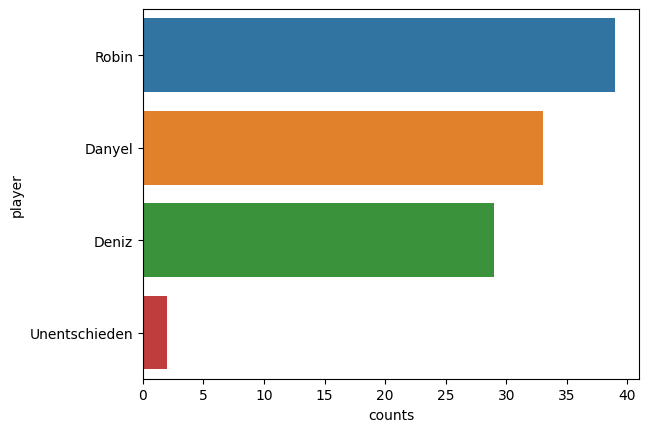

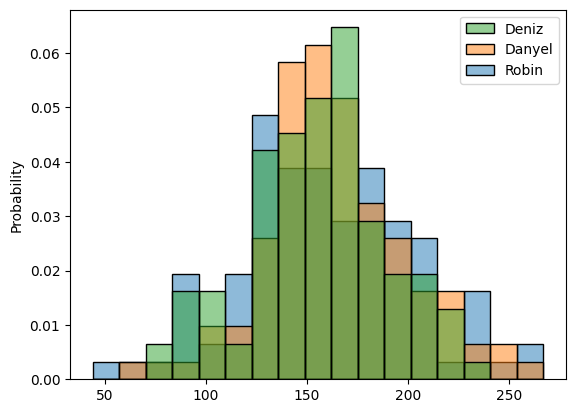

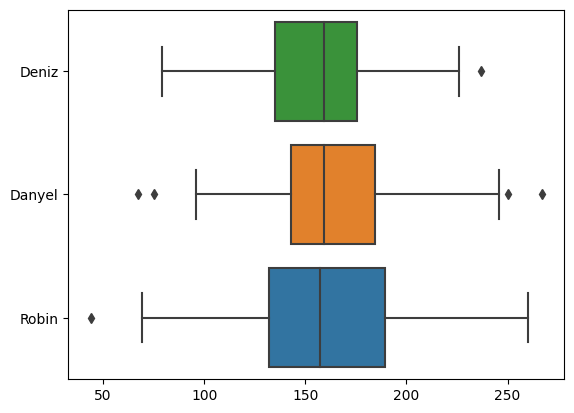

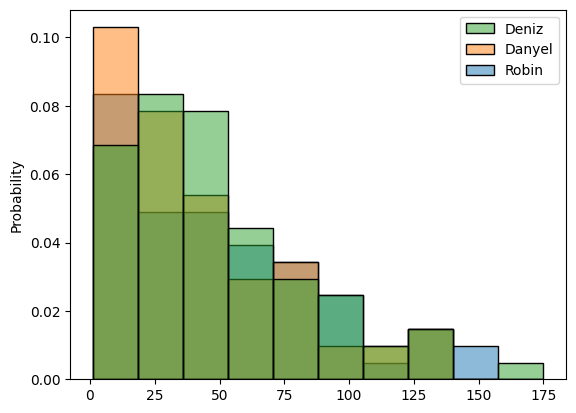

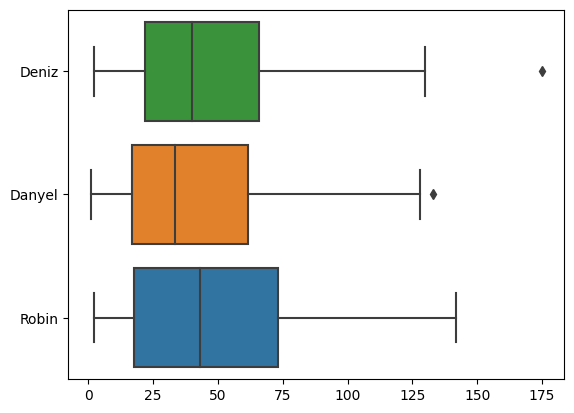

In [34]:
player_selection = pn.widgets.CheckButtonGroup(value=scrabble_players, options=scrabble_players)

score_distribution = pn.bind(get_score_distribution, players=player_selection)
score_distance_to_winner = pn.bind(get_score_distance_to_winner_distribution, players=player_selection)

dashboard = pn.template.MaterialTemplate(title='Scrabble')

dashboard.sidebar.append(player_selection)

dashboard.main.append(
    pn.GridBox(*[get_win_distribution(), get_player_stats(), score_distribution, score_distance_to_winner], ncols=2)
)

dashboard.show()